
# Coordinate Search on the Branin--Hoo Function

This notebook gives a **step-by-step demonstration** of the classical **Coordinate Search** method on the Branin--Hoo function.

The notebook does four things:

1. defines the Branin--Hoo objective,
2. implements a simple coordinate search method,
3. records every accepted/rejected coordinate move,
4. visualizes the algorithm trajectory and the trial points at each iteration.

The method is intentionally kept simple and transparent.



## 1. Coordinate Search in plain terms

Coordinate Search is a derivative-free optimization method.  
At a current point $\mathbf{x}_k$, instead of using gradients, it probes the objective along coordinate directions:

$\pm e_1,\; \pm e_2,\; \dots,\; \pm e_n.$

For a step size $\Delta_k$, the method evaluates points such as
$
\mathbf{x}_k + \Delta_k e_i
\quad\text{and}\quad
\mathbf{x}_k - \Delta_k e_i.
$

If one of these trial points improves the objective, the method accepts the best improving move.  
If no coordinate move improves the objective, the method reduces the step size.

This notebook uses the following simple logic:

- start at an initial point $\mathbf{x}_0$,
- try the four moves in 2D:
  $
  ( +\Delta, 0),\; (-\Delta, 0),\; (0, +\Delta),\; (0, -\Delta),
  $
- accept the best improving move if one exists,
- otherwise shrink $\Delta$,
- stop once $\Delta$ becomes sufficiently small or a maximum number of iterations is reached.


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from IPython.display import display, Math

# Plot settings
plt.rcParams.update({
    "figure.figsize": (9, 7.0),
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

# If you have a full LaTeX installation and want external LaTeX rendering,
# you may uncomment the next line.
plt.rcParams["text.usetex"] = True



## 2. The Branin--Hoo function

We use the standard Branin--Hoo test function:
$
f(x_1,x_2)
=
a\left(x_2-bx_1^2+cx_1-r\right)^2
+s(1-t)\cos(x_1)+s,
$
with parameters
$
a=1,\quad
b=\frac{5.1}{4\pi^2},\quad
c=\frac{5}{\pi},\quad
r=6,\quad
s=10,\quad
t=\frac{1}{8\pi}.
$

The usual domain is
$
x_1 \in [-5,10],\qquad x_2 \in [0,15].
$

This function is useful for teaching because it is smooth, nonconvex, and has multiple global minimizers.


In [17]:
def branin(x):
    x1, x2 = x
    a = 1.0
    b = 5.1 / (4.0 * np.pi**2)
    c = 5.0 / np.pi
    r = 6.0
    s = 10.0
    t = 1.0 / (8.0 * np.pi)
    return a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1.0 - t) * np.cos(x1) + s

# Known global minimizers of Branin
branin_minimizers = np.array([
    [-np.pi, 12.275],
    [ np.pi,  2.275],
    [ 9.42478, 2.475],
])

for p in branin_minimizers:
    print(f"x = {p}, f(x) = {branin(p):.8f}")


x = [-3.14159265 12.275     ], f(x) = 0.39788736
x = [3.14159265 2.275     ], f(x) = 0.39788736
x = [9.42478 2.475  ], f(x) = 0.39788736


In [18]:
# Build a contour grid for later plots
x1 = np.linspace(-5, 10, 500)
x2 = np.linspace(0, 15, 500)
X1, X2 = np.meshgrid(x1, x2)
Z = branin((X1, X2))


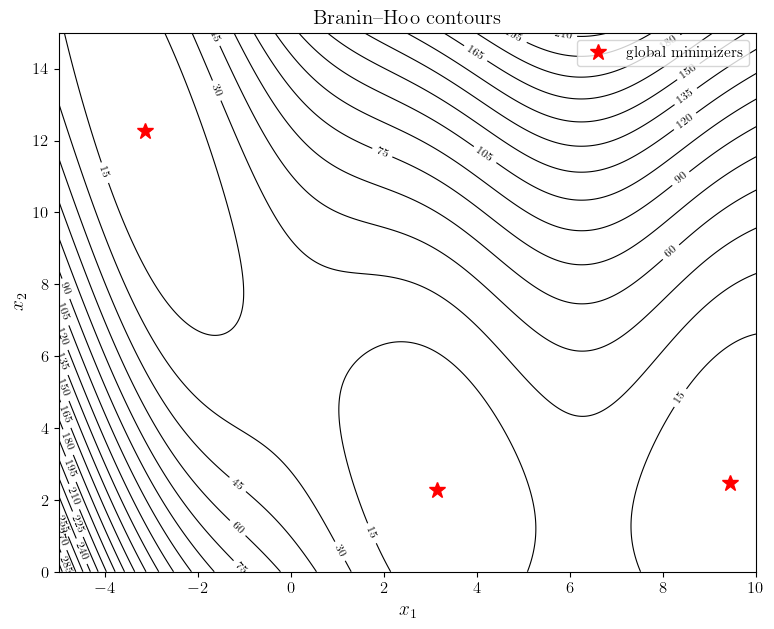

In [39]:
def plot_branin_contours(ax=None, levels=40):
    if ax is None:
        fig, ax = plt.subplots()
    cs = ax.contour(X1, X2, Z, levels=levels, colors="black", linewidths=0.8)
    ax.clabel(cs, inline=True, fontsize=8, fmt="%.0f")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title(r"Branin--Hoo contours")
    ax.set_xlim([-5, 10])
    ax.set_ylim([0, 15])
    return ax

fig, ax = plt.subplots()
plot_branin_contours(ax=ax, levels=25)
ax.plot(branin_minimizers[:,0], branin_minimizers[:,1], "r*", ms=12, label="global minimizers")
ax.legend(loc="upper right")
plt.savefig("figures/branin.png")
# plt.show()



## 3. Coordinate Search implementation

We now implement a basic coordinate search method in 2D.

At each major iteration:

1. evaluate the four coordinate trial points,
2. select the **best improving** one, if any,
3. accept it and keep the same step size,
4. otherwise reduce the step size.

For teaching purposes, we record:

- the incumbent point,
- all trial points,
- which points improve,
- whether a move was accepted,
- the objective value and step size history.


In [40]:
def coordinate_search(
    f,
    x0,
    delta0=1.0,
    shrink=0.5,
    delta_min=1e-3,
    max_iters=40,
    bounds=None,
):
    x = np.array(x0, dtype=float)
    delta = float(delta0)
    n = len(x)

    history = []
    accepted_points = [x.copy()]
    f_values = [f(x)]
    step_sizes = [delta]

    directions = np.eye(n)

    for k in range(max_iters):
        fx = f(x)
        trials = []

        for i in range(n):
            for sign in [+1.0, -1.0]:
                xt = x + sign * delta * directions[i]

                if bounds is not None:
                    lb = np.array([b[0] for b in bounds], dtype=float)
                    ub = np.array([b[1] for b in bounds], dtype=float)
                    xt = np.minimum(np.maximum(xt, lb), ub)

                ft = f(xt)
                trials.append({
                    "coord": i,
                    "sign": sign,
                    "x_trial": xt.copy(),
                    "f_trial": ft,
                    "improves": ft < fx,
                })

        improving_trials = [t for t in trials if t["f_trial"] < fx]

        if improving_trials:
            best_trial = min(improving_trials, key=lambda d: d["f_trial"])
            x_new = best_trial["x_trial"].copy()
            fx_new = best_trial["f_trial"]
            accepted = True
        else:
            best_trial = None
            x_new = x.copy()
            fx_new = fx
            accepted = False

        history.append({
            "iter": k,
            "x": x.copy(),
            "f": fx,
            "delta": delta,
            "trials": trials,
            "accepted": accepted,
            "best_trial": best_trial,
            "x_new": x_new.copy(),
            "f_new": fx_new,
        })

        if accepted:
            x = x_new
            accepted_points.append(x.copy())
            f_values.append(fx_new)
            step_sizes.append(delta)
        else:
            delta *= shrink
            step_sizes.append(delta)

        if delta < delta_min:
            break

    result = {
        "x_best": x,
        "f_best": f(x),
        "history": history,
        "accepted_points": np.array(accepted_points),
        "f_values": np.array(f_values),
        "step_sizes": np.array(step_sizes),
    }
    return result



## 4. Run the method from a chosen starting point

You can change the starting point below to illustrate different trajectories.  
For a short course, it is often useful to pick a point that is clearly not near a minimizer so that the algorithm behavior is visible.


In [41]:
bounds = [(-5.0, 10.0), (0.0, 15.0)]

x0 = np.array([6.0, 10.0])   # change this if desired
delta0 = 1.5
result = coordinate_search(
    branin,
    x0=x0,
    delta0=delta0,
    shrink=0.5,
    delta_min=1e-3,
    max_iters=50,
    bounds=bounds,
)

print("Best point found:", result["x_best"])
print("Best objective :", result["f_best"])
print("Number of major iterations recorded:", len(result["history"]))
print("Number of accepted moves:", len(result["accepted_points"]) - 1)


Best point found: [3.14208984 2.27441406]
Best objective : 0.3978885838370694
Number of major iterations recorded: 26
Number of accepted moves: 15


In [42]:
# Display the first few major iterations in a compact text form
for rec in result["history"][:8]:
    print("-" * 70)
    print(f"Iteration {rec['iter']:2d}")
    print(f"Current point   : {rec['x']}")
    print(f"Current value   : {rec['f']:.6f}")
    print(f"Step size delta : {rec['delta']:.6f}")
    print(f"Accepted move?  : {rec['accepted']}")
    if rec["accepted"]:
        print(f"New point       : {rec['x_new']}")
        print(f"New value       : {rec['f_new']:.6f}")
    else:
        print("No improving coordinate move found.")


----------------------------------------------------------------------
Iteration  0
Current point   : [ 6. 10.]
Current value   : 98.405711
Step size delta : 1.500000
Accepted move?  : True
New point       : [6.  8.5]
New value       : 73.959748
----------------------------------------------------------------------
Iteration  1
Current point   : [6.  8.5]
Current value   : 73.959748
Step size delta : 1.500000
Accepted move?  : True
New point       : [6. 7.]
New value       : 54.013785
----------------------------------------------------------------------
Iteration  2
Current point   : [6. 7.]
Current value   : 54.013785
Step size delta : 1.500000
Accepted move?  : True
New point       : [6.  5.5]
New value       : 38.567823
----------------------------------------------------------------------
Iteration  3
Current point   : [6.  5.5]
Current value   : 38.567823
Step size delta : 1.500000
Accepted move?  : True
New point       : [4.5 5.5]
New value       : 24.345919
--------------------


## 5. Full trajectory on the Branin--Hoo contours

The plot below shows the accepted path of the coordinate search method over the contour lines of the objective.


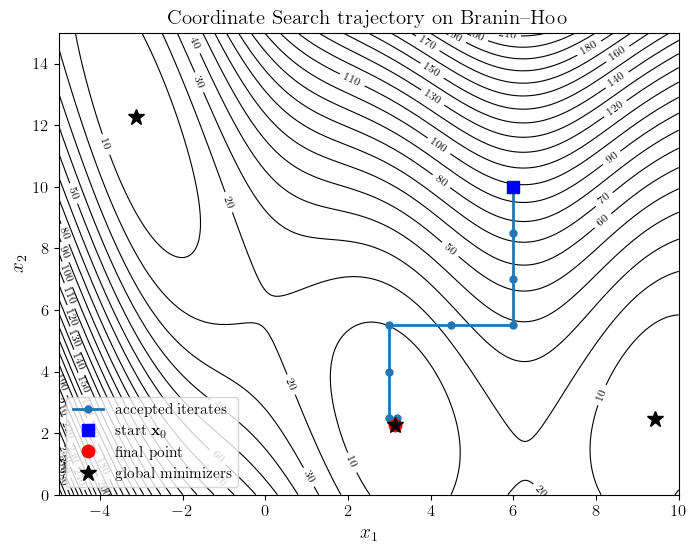

In [49]:
def plot_trajectory(result, show_minimizers=True):
    pts = result["accepted_points"]

    fig, ax = plt.subplots(figsize=(8, 6))
    plot_branin_contours(ax=ax, levels=35)

    ax.plot(pts[:, 0], pts[:, 1], "-o", lw=2, ms=5, label=r"accepted iterates")
    ax.plot(pts[0, 0], pts[0, 1], "bs", ms=9, label=r"start $\mathbf{x}_0$")
    ax.plot(pts[-1, 0], pts[-1, 1], "ro", ms=9, label=r"final point")

    if show_minimizers:
        ax.plot(branin_minimizers[:,0], branin_minimizers[:,1], "k*", ms=12, label="global minimizers")

    ax.legend(loc="lower left")
    ax.set_title(r"Coordinate Search trajectory on Branin--Hoo")
    # plt.show()
    plt.savefig("figures/branin_cs.png")

plot_trajectory(result)



## 6. Objective history and step-size history

Coordinate search typically shows a pattern like this:

- the objective decreases when an improving coordinate move is found,
- the step size remains unchanged while successful moves are being found,
- the step size drops when the method stalls locally at the current resolution.


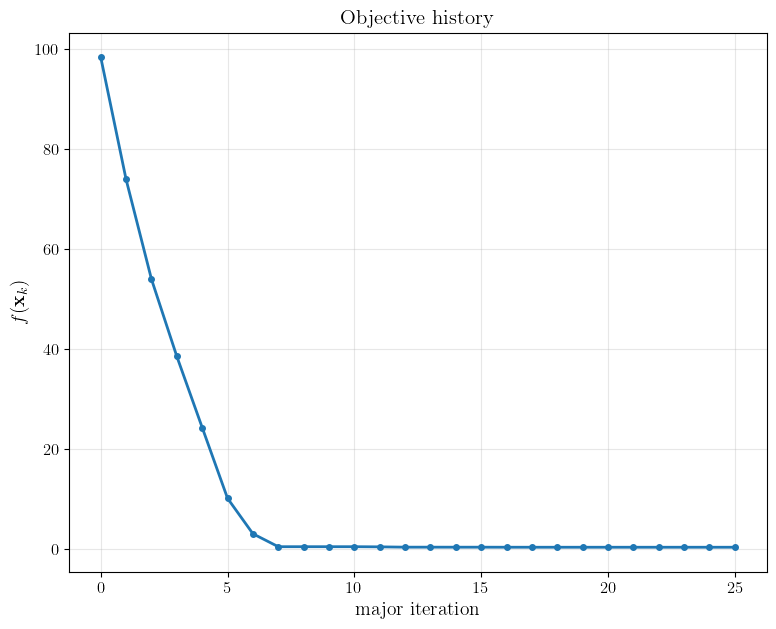

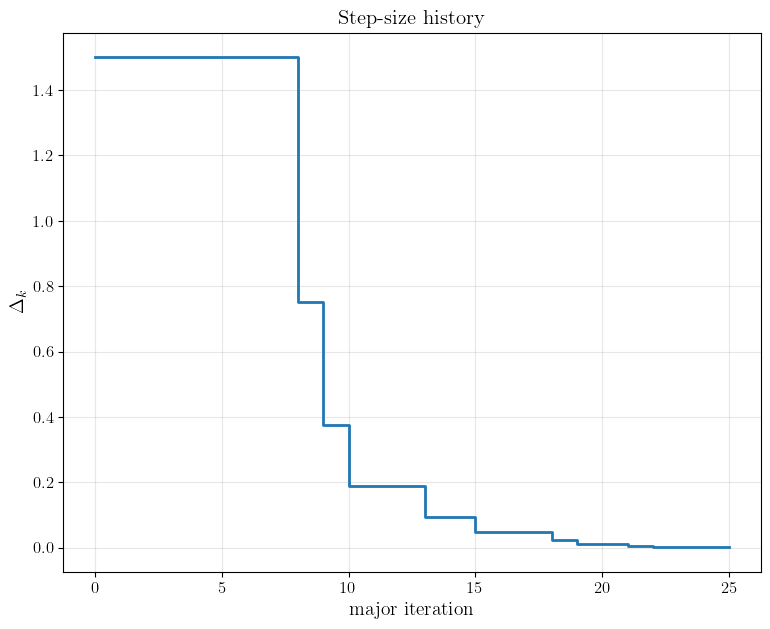

In [44]:
def plot_histories(result):
    hist = result["history"]
    iters = np.arange(len(hist))
    f_major = np.array([h["f"] for h in hist])
    delta_major = np.array([h["delta"] for h in hist])

    fig, ax = plt.subplots()
    ax.plot(iters, f_major, "-o", lw=2, ms=4)
    ax.set_xlabel("major iteration")
    ax.set_ylabel(r"$f(\mathbf{x}_k)$")
    ax.set_title(r"Objective history")
    ax.grid(True, alpha=0.3)
    plt.savefig("figures/branin_fk.png")
    

    fig, ax = plt.subplots()
    ax.step(iters, delta_major, where="post", lw=2)
    ax.set_xlabel("major iteration")
    ax.set_ylabel(r"$\Delta_k$")
    ax.set_title(r"Step-size history")
    ax.grid(True, alpha=0.3)
    plt.savefig("figures/branin_deltak.png")
    

plot_histories(result)



## 7. Inspect one major iteration in detail

The next function visualizes a **single major iteration**.  
It shows:

- the current point $\mathbf{x}_k$,
- all four coordinate trial points,
- which trial points improve the objective,
- the accepted move, if any,
- a circle of radius $\Delta_k$ centered at $\mathbf{x}_k$ to emphasize the local search radius.

This is useful when teaching the method step-by-step.


In [50]:
def plot_iteration_detail(result, k):
    rec = result["history"][k]
    xk = rec["x"]
    delta = rec["delta"]

    fig, ax = plt.subplots(figsize=(8, 6))
    plot_branin_contours(ax=ax, levels=30)

    # Current point
    ax.plot(xk[0], xk[1], "bo", ms=9, label=rf"current point $\mathbf{{x}}_{k}$")

    # Search circle for visualization
    circ = Circle((xk[0], xk[1]), radius=delta, fill=False, ls="--", lw=1.5, alpha=0.8)
    ax.add_patch(circ)

    # Trial points
    for t in rec["trials"]:
        xt = t["x_trial"]
        if t["improves"]:
            ax.plot(xt[0], xt[1], "g^", ms=8)
            ax.plot([xk[0], xt[0]], [xk[1], xt[1]], "g--", lw=1.5, alpha=0.8)
        else:
            ax.plot(xt[0], xt[1], "rx", ms=8, mew=2)
            ax.plot([xk[0], xt[0]], [xk[1], xt[1]], "r:", lw=1.0, alpha=0.7)

    # Accepted point if any
    if rec["accepted"]:
        xn = rec["x_new"]
        ax.plot(xn[0], xn[1], "mo", ms=9, label=rf"accepted point $\mathbf{{x}}_{{{k+1}}}$")
        ax.annotate(
            "",
            xy=(xn[0], xn[1]),
            xytext=(xk[0], xk[1]),
            arrowprops=dict(arrowstyle="->", lw=2),
        )

    ax.set_title(
        rf"Iteration {k}: $f(\mathbf{{x}}_k)={rec['f']:.3f}$, $\Delta_k={delta:.3f}$"
    )

    improve_proxy = plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="g",
                               markersize=9, label="improving trial")
    reject_proxy = plt.Line2D([0], [0], marker="x", color="r",
                              markersize=9, lw=0, label="non-improving trial")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + [improve_proxy, reject_proxy],
              labels + ["improving trial", "non-improving trial"],
              loc="upper left")
    


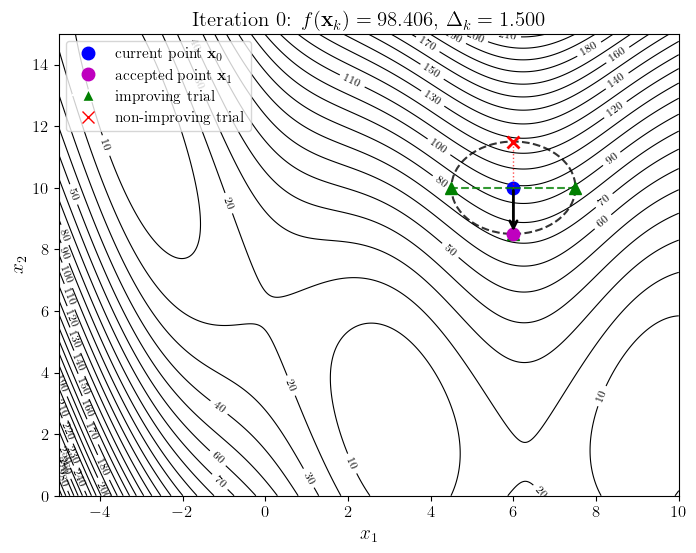

In [52]:
# Change k to inspect different major iterations
k = 0
plot_iteration_detail(result, k)
plt.savefig(f"figures/branincs_iter{k}.png")

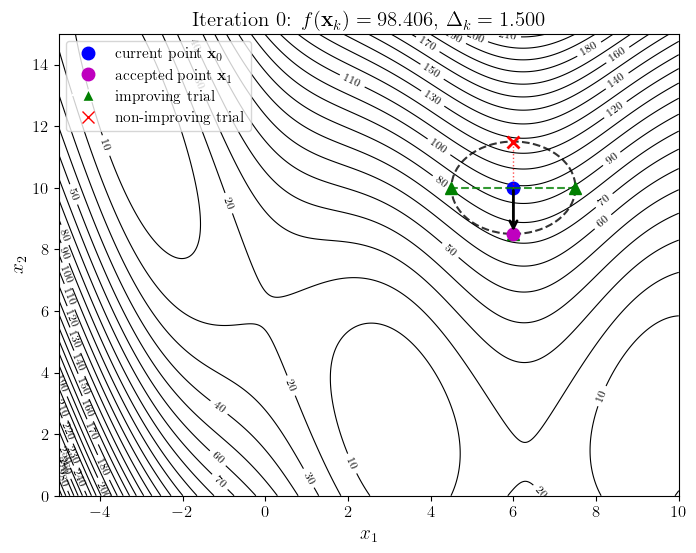

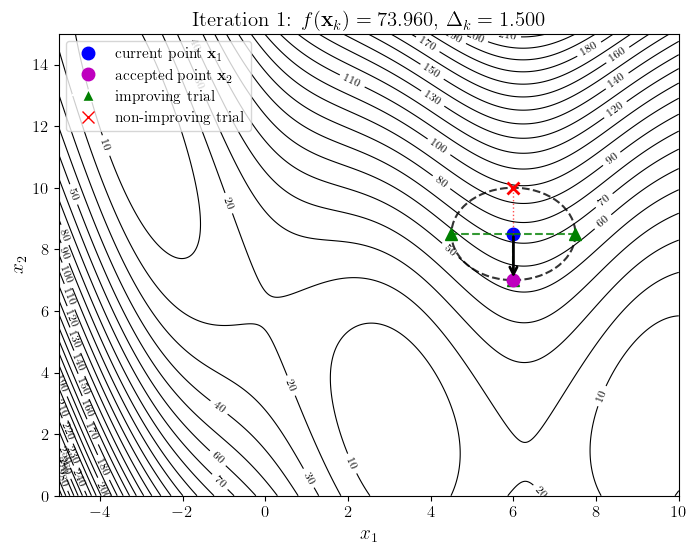

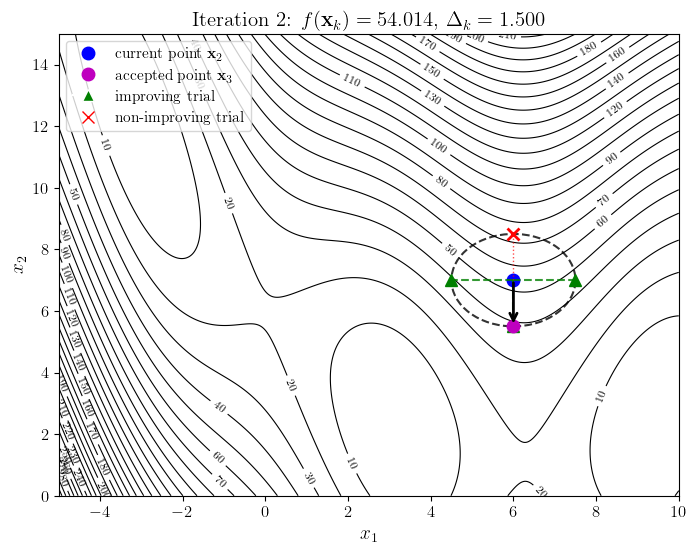

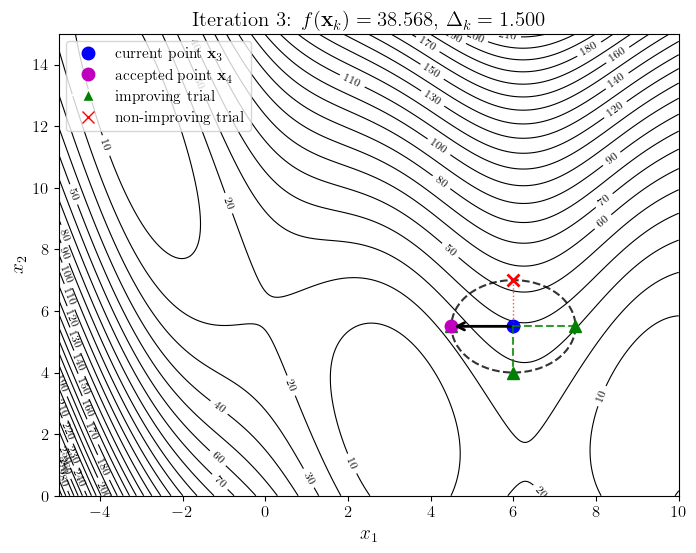

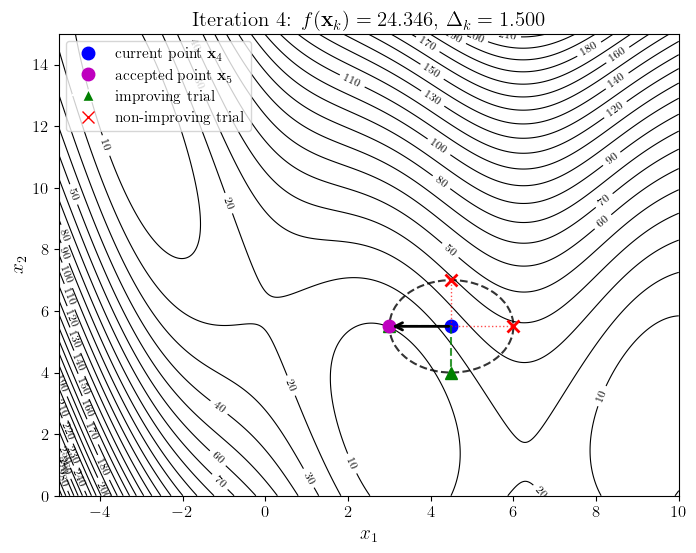

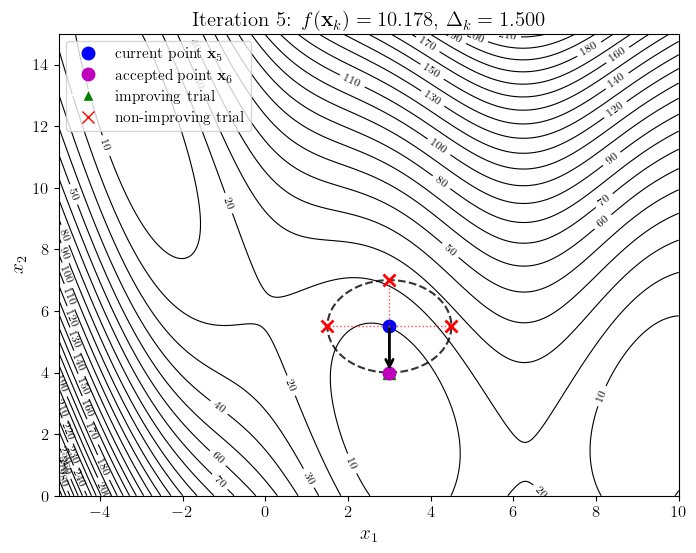

In [53]:
# Show a sequence of early iterations
for k in range(min(6, len(result["history"]))):
    plot_iteration_detail(result, k)
    plt.savefig(f"figures/branincs_iter{k}.png")


## 8. Tabulate the trial points for a given iteration

Sometimes, for an industrial audience, a simple table is useful in addition to plots.
The function below prints all trial points for a given major iteration.


In [13]:
def print_iteration_table(result, k):
    rec = result["history"][k]
    xk = rec["x"]
    fx = rec["f"]
    delta = rec["delta"]

    print("=" * 95)
    print(f"Iteration {k}")
    print(f"Current point: x_k = {xk},   f(x_k) = {fx:.6f},   delta = {delta:.6f}")
    print("-" * 95)
    print(f"{'coord':>8} {'sign':>8} {'x_trial':>28} {'f(x_trial)':>16} {'improves?':>12}")
    print("-" * 95)
    for t in rec["trials"]:
        sgn = "+" if t["sign"] > 0 else "-"
        print(f"{t['coord']+1:>8d} {sgn:>8s} {np.array2string(t['x_trial'], precision=4):>28s} "
              f"{t['f_trial']:>16.6f} {str(t['improves']):>12s}")
    print("-" * 95)
    if rec["accepted"]:
        print(f"Accepted best move to {rec['x_new']} with objective {rec['f_new']:.6f}")
    else:
        print("No improving move found. Step size should be reduced.")

print_iteration_table(result, 0)


Iteration 0
Current point: x_k = [ 8. 12.],   f(x_k) = 118.110470,   delta = 1.500000
-----------------------------------------------------------------------------------------------
   coord     sign                      x_trial       f(x_trial)    improves?
-----------------------------------------------------------------------------------------------
       1        +                  [ 9.5 12. ]        89.932111         True
       1        -                  [ 6.5 12. ]       137.904635        False
       2        +                  [ 8.  13.5]       151.754231        False
       2        -                  [ 8.  10.5]        88.966710         True
-----------------------------------------------------------------------------------------------
Accepted best move to [ 8.  10.5] with objective 88.966710



## 9. A compact animation-style walkthrough

The next helper redraws the full search state at each major iteration.  
Running the cell will display each major iteration in sequence.


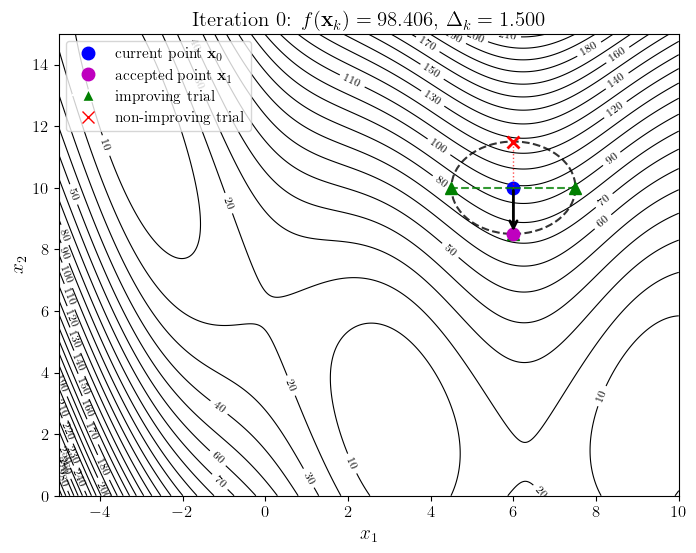

Iteration 0
Current point: x_k = [ 6. 10.],   f(x_k) = 98.405711,   delta = 1.500000
-----------------------------------------------------------------------------------------------
   coord     sign                      x_trial       f(x_trial)    improves?
-----------------------------------------------------------------------------------------------
       1        +                  [ 7.5 10. ]        88.497194         True
       1        -                  [ 4.5 10. ]        81.009794         True
       2        +                  [ 6.  11.5]       127.351674        False
       2        -                    [6.  8.5]        73.959748         True
-----------------------------------------------------------------------------------------------
Accepted best move to [6.  8.5] with objective 73.959748


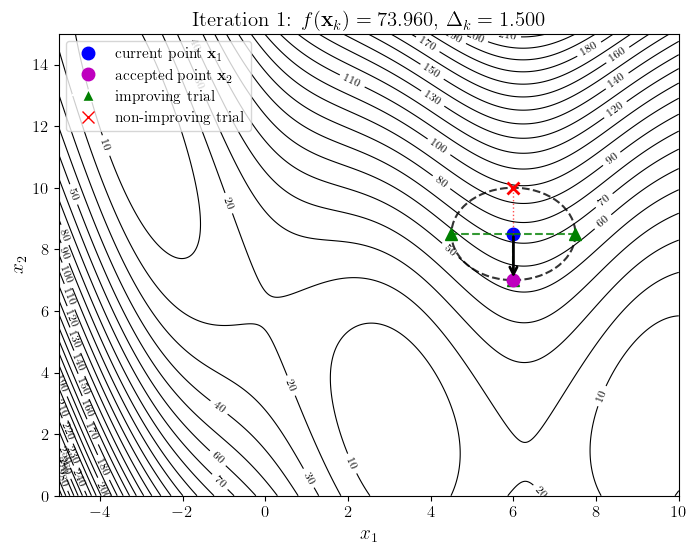

Iteration 1
Current point: x_k = [6.  8.5],   f(x_k) = 73.959748,   delta = 1.500000
-----------------------------------------------------------------------------------------------
   coord     sign                      x_trial       f(x_trial)    improves?
-----------------------------------------------------------------------------------------------
       1        +                    [7.5 8.5]        64.737218         True
       1        -                    [4.5 8.5]        57.621836         True
       2        +                    [ 6. 10.]        98.405711        False
       2        -                      [6. 7.]        54.013785         True
-----------------------------------------------------------------------------------------------
Accepted best move to [6. 7.] with objective 54.013785


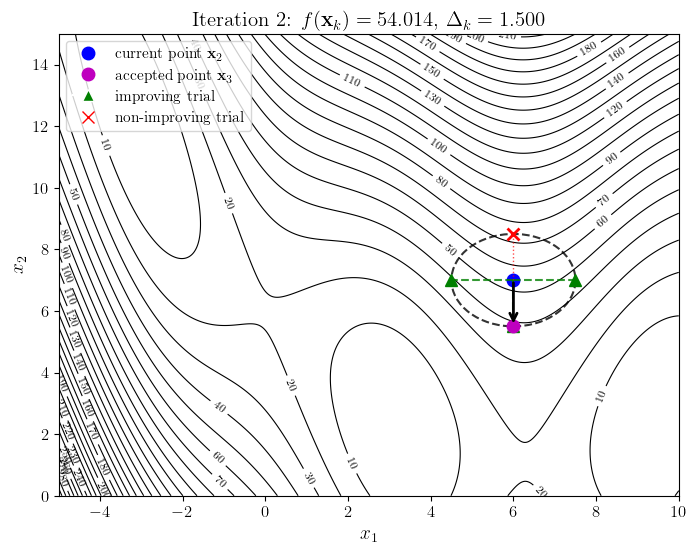

Iteration 2
Current point: x_k = [6. 7.],   f(x_k) = 54.013785,   delta = 1.500000
-----------------------------------------------------------------------------------------------
   coord     sign                      x_trial       f(x_trial)    improves?
-----------------------------------------------------------------------------------------------
       1        +                    [7.5 7. ]        45.477242         True
       1        -                    [4.5 7. ]        38.733877         True
       2        +                    [6.  8.5]        73.959748        False
       2        -                    [6.  5.5]        38.567823         True
-----------------------------------------------------------------------------------------------
Accepted best move to [6.  5.5] with objective 38.567823


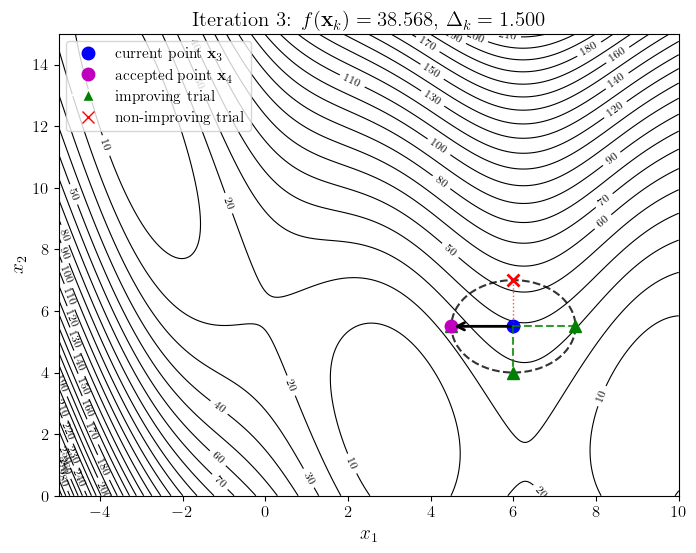

Iteration 3
Current point: x_k = [6.  5.5],   f(x_k) = 38.567823,   delta = 1.500000
-----------------------------------------------------------------------------------------------
   coord     sign                      x_trial       f(x_trial)    improves?
-----------------------------------------------------------------------------------------------
       1        +                    [7.5 5.5]        30.717265         True
       1        -                    [4.5 5.5]        24.345919         True
       2        +                      [6. 7.]        54.013785        False
       2        -                      [6. 4.]        27.621860         True
-----------------------------------------------------------------------------------------------
Accepted best move to [4.5 5.5] with objective 24.345919


In [35]:
def walkthrough(result, nsteps=None):
    if nsteps is None:
        nsteps = len(result["history"])
    for k in range(min(nsteps, len(result["history"]))):
        plot_iteration_detail(result, k)
        print_iteration_table(result, k)

# Example:
walkthrough(result, nsteps=4)



## 10. Discussion points for teaching

A few points worth emphasizing during the course:

The method is **derivative-free**. It never computes $\nabla f$ or Hessians.

The method is **local**. It only probes nearby coordinate directions at a given scale $\Delta_k$.

The step size $\Delta_k$ plays a central role.  
A large $\Delta_k$ helps the method explore.  
A small $\Delta_k$ helps refine the solution.

Coordinate Search is easy to implement and robust, but it can be slower than gradient-based methods on smooth problems, especially in higher dimensions.

On a multimodal function such as Branin--Hoo, the final point depends on the starting point and the step-size policy.



## 11. Try your own starting point

For teaching, it is useful to re-run the method from different starting points to show sensitivity to initialization.
Examples:

- near the upper-left basin,
- near the center,
- near the right-hand basin.

Modify `x0` and `delta0` below and re-run.


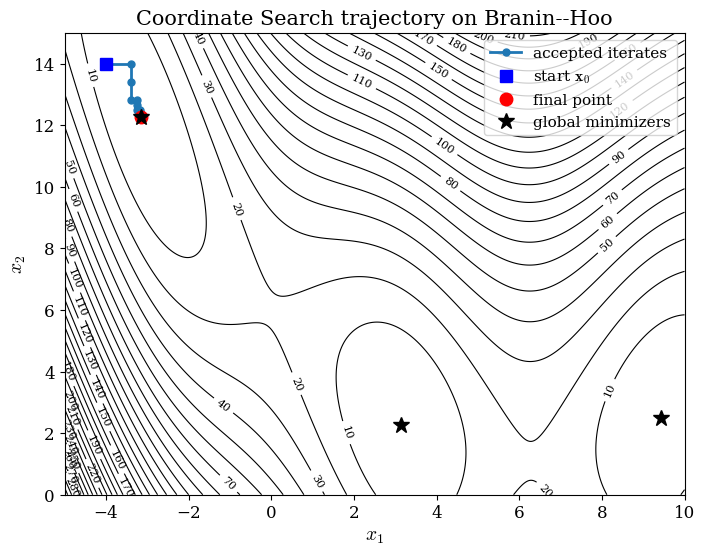

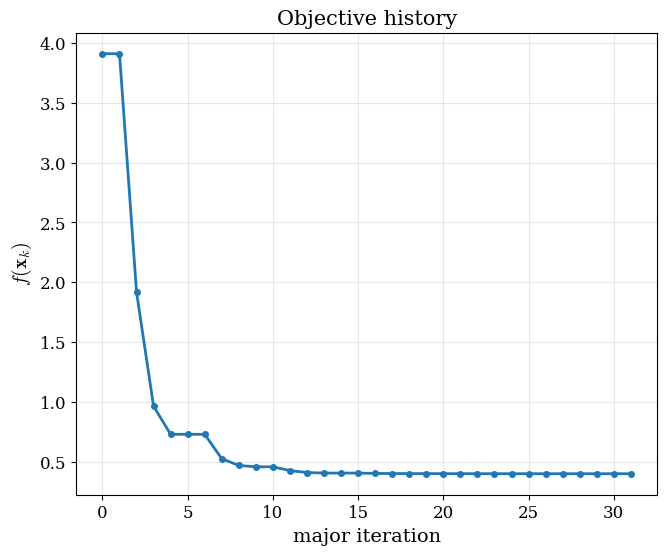

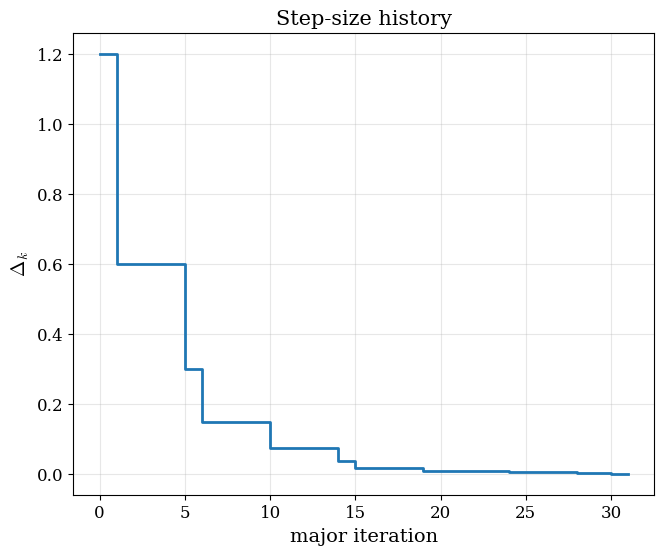

In [15]:
# Try a second run if desired
x0_alt = np.array([-4.0, 14.0])
result_alt = coordinate_search(
    branin,
    x0=x0_alt,
    delta0=1.2,
    shrink=0.5,
    delta_min=1e-3,
    max_iters=50,
    bounds=bounds,
)

plot_trajectory(result_alt)
plot_histories(result_alt)



## 12. Takeaway

Coordinate Search is one of the most intuitive derivative-free methods:

\[
\text{probe} \;\rightarrow\; \text{compare} \;\rightarrow\; \text{move or shrink}.
\]

That makes it especially suitable for an introductory DFO module for practitioners who want to understand the mechanics of optimization without first introducing gradients or surrogate models.
